# **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib

from scipy                import stats
from sklearn.metrics      import (
    roc_curve, auc, precision_recall_curve,
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="ticks", context="paper", font_scale=1.2, palette="Set1")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/Datasets/Final Project/Processed/'

y_test       = pd.read_parquet(f'{BASE}y_test.parquet')['Is Laundering']
proba_nb     = pd.read_parquet(f'{BASE}y_proba_nb.parquet')['y_proba_nb'].values
proba_lr     = pd.read_parquet(f'{BASE}y_proba_lr.parquet')['y_proba_lr'].values
proba_xgb    = pd.read_parquet(f'{BASE}y_proba_xgb.parquet')['y_proba_xgb'].values

y_true = y_test.values

MODELS = {
    'Naive Bayes'       : proba_nb,
    'Ridge (LR)'        : proba_lr,
    'XGBoost'           : proba_xgb,
}

COLORS = {
    'Naive Bayes'       : '#E41A1C',
    'Ridge (LR)'        : '#377EB8',
    'XGBoost'           : '#4DAF4A',
}

Mounted at /content/drive


# **Funciones Auxiliares**

In [3]:
def compute_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
    return {
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred, zero_division=0),
        'Recall'    : recall_score(y_true, y_pred, zero_division=0),
        'F1'        : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_true, y_proba),
        'PR-AUC'    : auc(rec_c, prec_c),
    }


def delong_test(y_true, proba_a, proba_b):
    """
    Test de DeLong para comparar dos AUCs.
    Retorna (auc_a, auc_b, diferencia, z_stat, p_value).
    Implementación basada en Sun & Xu (2014).
    """
    def _placement_values(y_true, proba):
        pos = proba[y_true == 1]
        neg = proba[y_true == 0]
        # V10: para cada positivo, fracción de negativos que están por debajo
        V10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
        # V01: para cada negativo, fracción de positivos que están por encima
        V01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
        return V10, V01

    n1 = np.sum(y_true == 1)
    n0 = np.sum(y_true == 0)

    V10_a, V01_a = _placement_values(y_true, proba_a)
    V10_b, V01_b = _placement_values(y_true, proba_b)

    auc_a = V10_a.mean()
    auc_b = V10_b.mean()

    # Matriz de covarianza de los AUCs usando las placement values
    S10 = np.cov(V10_a, V10_b) / n1
    S01 = np.cov(V01_a, V01_b) / n0

    var_diff = S10[0,0] + S01[0,0] - 2*S10[0,1] - 2*S01[0,1] + \
               S10[1,1] + S01[1,1]

    if var_diff <= 0:
        return auc_a, auc_b, auc_a - auc_b, np.nan, np.nan

    z   = (auc_a - auc_b) / np.sqrt(var_diff)
    p   = 2 * (1 - stats.norm.cdf(abs(z)))

    return auc_a, auc_b, auc_a - auc_b, z, p


def bootstrap_ci(y_true, y_proba, metric_fn, n_bootstrap=1000, ci=0.95, seed=42):
    """
    Estima IC por bootstrap para una métrica dada.
    metric_fn debe aceptar (y_true, y_proba) y retornar un escalar.
    """
    rng = np.random.default_rng(seed)
    n   = len(y_true)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], y_proba[idx]))

    alpha = (1 - ci) / 2
    return (
        np.mean(scores),
        np.percentile(scores, alpha * 100),
        np.percentile(scores, (1 - alpha) * 100),
    )

# **Tabla Comparativa**

             Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Modelo                                                           
Naive Bayes    0.9020     0.0160  0.8999  0.0315   0.9445  0.0496
Ridge (LR)     0.9506     0.0317  0.9105  0.0612   0.9827  0.2621
XGBoost        0.9986     0.8646  0.2380  0.3733   0.9698  0.4442


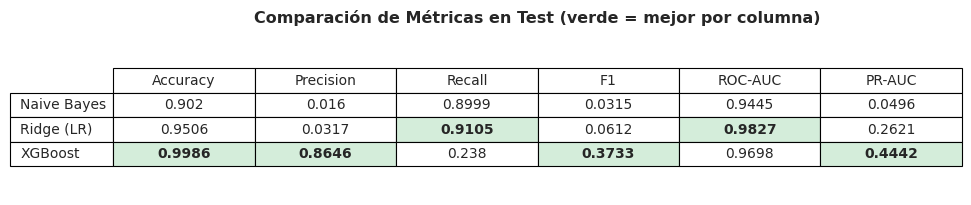

In [4]:
rows = []
for name, proba in MODELS.items():
    m = compute_metrics(y_true, proba)
    m['Modelo'] = name
    rows.append(m)

metrics_df = (
    pd.DataFrame(rows)
    .set_index('Modelo')
    [['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']]
)

print(metrics_df.round(4).to_string())

# Visualización de la tabla
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis('off')
tbl = ax.table(
    cellText   = metrics_df.round(4).values,
    rowLabels  = metrics_df.index.tolist(),
    colLabels  = metrics_df.columns.tolist(),
    cellLoc    = 'center',
    loc        = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)

# Resaltar la mejor celda por columna
for j, col in enumerate(metrics_df.columns):
    best_row = metrics_df[col].idxmax()
    best_i   = metrics_df.index.tolist().index(best_row)
    tbl[best_i + 1, j].set_facecolor('#d4edda')
    tbl[best_i + 1, j].set_text_props(fontweight='bold')

plt.title('Comparación de Métricas en Test (verde = mejor por columna)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# **Curvas ROC**

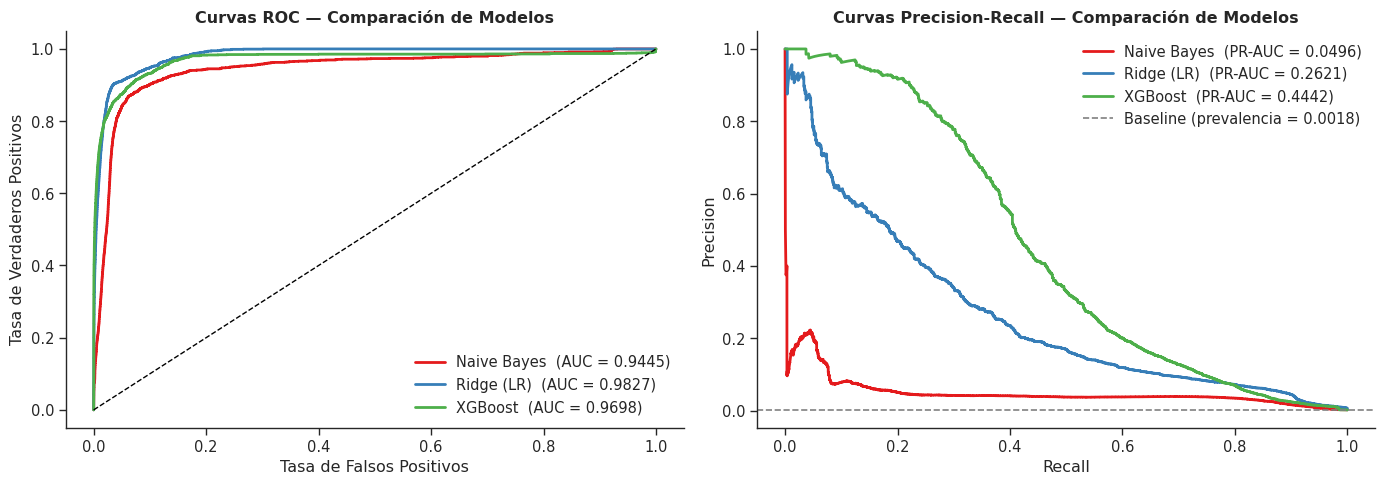

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in MODELS.items():
    fpr, tpr, _ = roc_curve(y_true, proba)
    roc_auc     = auc(fpr, tpr)
    prec_c, rec_c, _ = precision_recall_curve(y_true, proba)
    pr_auc      = auc(rec_c, prec_c)
    color       = COLORS[name]

    axes[0].plot(fpr, tpr, lw=2, color=color, label=f"{name}  (AUC = {roc_auc:.4f})")
    axes[1].plot(rec_c, prec_c, lw=2, color=color, label=f"{name}  (PR-AUC = {pr_auc:.4f})")

# ROC
axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].set_title('Curvas ROC — Comparación de Modelos', fontweight='bold')
axes[0].legend(frameon=False)

# PR
axes[1].axhline(y_true.mean(), color='gray', linestyle='--', lw=1.2,
                label=f'Baseline (prevalencia = {y_true.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas Precision-Recall — Comparación de Modelos', fontweight='bold')
axes[1].legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

# **Test DeLong**

In [6]:
print(f"  {'Modelo A':<15} {'Modelo B':<15} {'AUC A':>8} {'AUC B':>8} {'Δ AUC':>8} {'Z':>8} {'p-valor':>10}")
print(f"  {'─'*73}")

model_names = list(MODELS.keys())
delong_rows = []

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name_a, name_b = model_names[i], model_names[j]
        auc_a, auc_b, diff, z, p = delong_test(y_true, MODELS[name_a], MODELS[name_b])
        sig = '✓' if (p is not np.nan and p < 0.05) else ''
        print(f"  {name_a:<15} {name_b:<15} {auc_a:>8.4f} {auc_b:>8.4f} {diff:>+8.4f} {z:>8.3f} {p:>10.4f} {sig}")
        delong_rows.append({
            'Modelo A'     : name_a,
            'Modelo B'     : name_b,
            'AUC A'        : round(auc_a, 4),
            'AUC B'        : round(auc_b, 4),
            'Δ AUC'        : round(diff, 4),
            'Z'            : round(z, 3),
            'p-valor'      : round(p, 4),
            'Significativo': 'Sí' if (p is not np.nan and p < 0.05) else 'No',
        })

print(f"\n  ✓ = diferencia significativa al nivel α=0.05")

delong_df = pd.DataFrame(delong_rows)

  Modelo A        Modelo B           AUC A    AUC B    Δ AUC        Z    p-valor
  ─────────────────────────────────────────────────────────────────────────
  Naive Bayes     Ridge (LR)        0.9445   0.9827  -0.0383  -14.531     0.0000 ✓
  Naive Bayes     XGBoost           0.9445   0.9698  -0.0253   -6.424     0.0000 ✓
  Ridge (LR)      XGBoost           0.9827   0.9698  +0.0129    4.589     0.0000 ✓

  ✓ = diferencia significativa al nivel α=0.05


# **Bootstrap**

  Naive Bayes     ROC-AUC        0.9444     0.9377     0.9504
  Naive Bayes     F1             0.0315     0.0299     0.0329
  Naive Bayes     PR-AUC         0.0496     0.0437     0.0560
  Ridge (LR)      ROC-AUC        0.9827     0.9808     0.9844
  Ridge (LR)      F1             0.0612     0.0583     0.0641
  Ridge (LR)      PR-AUC         0.2620     0.2401     0.2846
  XGBoost         ROC-AUC        0.9700     0.9646     0.9752
  XGBoost         F1             0.3738     0.3489     0.3990
  XGBoost         PR-AUC         0.4451     0.4211     0.4677


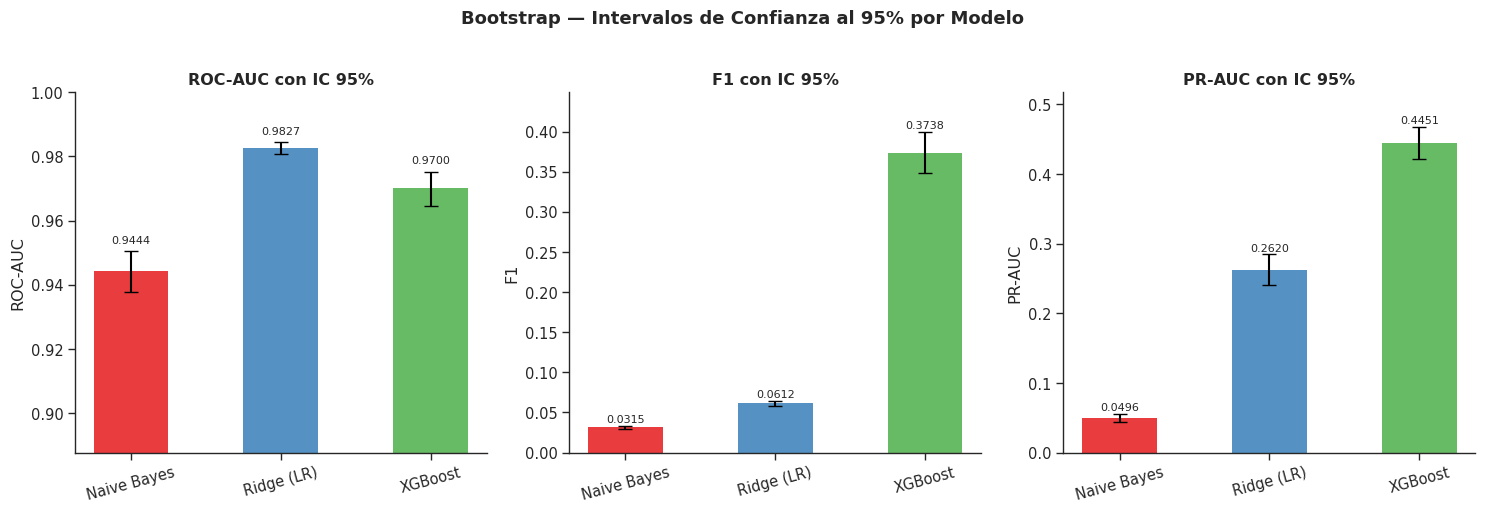

In [7]:
BOOTSTRAP_METRICS = {
    'ROC-AUC' : roc_auc_score,
    'F1'      : lambda yt, yp: f1_score(yt, (yp >= 0.5).astype(int), zero_division=0),
    'PR-AUC'  : lambda yt, yp: auc(*precision_recall_curve(yt, yp)[1::-1]),
}

bootstrap_rows = []

for name, proba in MODELS.items():
    for metric_name, metric_fn in BOOTSTRAP_METRICS.items():
        mean, lo, hi = bootstrap_ci(y_true, proba, metric_fn)
        print(f"  {name:<15} {metric_name:<12} {mean:>8.4f} {lo:>10.4f} {hi:>10.4f}")
        bootstrap_rows.append({
            'Modelo'   : name,
            'Métrica'  : metric_name,
            'Media'    : round(mean, 4),
            'IC Inf'   : round(lo, 4),
            'IC Sup'   : round(hi, 4),
        })

bootstrap_df = pd.DataFrame(bootstrap_rows)

# Visualización Bootstrap
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (metric_name, _) in zip(axes, BOOTSTRAP_METRICS.items()):
    subset = bootstrap_df[bootstrap_df['Métrica'] == metric_name].copy()
    colors = [COLORS[m] for m in subset['Modelo']]

    bars = ax.bar(subset['Modelo'], subset['Media'], color=colors,
                  alpha=0.85, edgecolor='none', width=0.5)

    # Barras de error = IC 95%
    ax.errorbar(
        subset['Modelo'],
        subset['Media'],
        yerr=[subset['Media'] - subset['IC Inf'], subset['IC Sup'] - subset['Media']],
        fmt='none', color='black', capsize=5, lw=1.5
    )

    for bar, (_, row) in zip(bars, subset.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2,
                row['IC Sup'] + 0.002,
                f"{row['Media']:.4f}", ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{metric_name} con IC 95%', fontweight='bold')
    ax.set_ylabel(metric_name)
    ax.tick_params(axis='x', rotation=15)
    ymin = max(0, subset['IC Inf'].min() - 0.05)
    ax.set_ylim(ymin, min(1.0, subset['IC Sup'].max() + 0.05))
    sns.despine(ax=ax)

plt.suptitle('Bootstrap — Intervalos de Confianza al 95% por Modelo',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


# **Exportacion de Resultados**

In [8]:
metrics_df.reset_index().to_parquet(f'{BASE}tabla_comparativa.parquet', index=False)
delong_df.to_parquet(f'{BASE}delong_results.parquet', index=False)
bootstrap_df.to_parquet(f'{BASE}bootstrap_results.parquet', index=False)

print(f"\n{'═'*60}")
print(f"  Archivos exportados a Drive:")
print(f"  - tabla_comparativa.parquet")
print(f"  - delong_results.parquet")
print(f"  - bootstrap_results.parquet")
print(f"{'═'*60}")


════════════════════════════════════════════════════════════
  Archivos exportados a Drive:
  - tabla_comparativa.parquet
  - delong_results.parquet
  - bootstrap_results.parquet
════════════════════════════════════════════════════════════
